# Load libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


# Load Dataset

In [2]:
df = pd.read_csv(r"/content/Algerian_forest_fires_dataset.csv")

# EDA

In [3]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [4]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(247, 14)


In [5]:
print("\nColumn Names:")
print(df.columns)



Column Names:
Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  '],
      dtype='object')


In [6]:

print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
dtypes: object(14)
memory usage: 27.1+ KB
None


In [7]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
day            1
month          2
year           2
Temperature    2
 RH            2
 Ws            2
Rain           2
FFMC           2
DMC            2
DC             2
ISI            2
BUI            2
FWI            2
Classes        3
dtype: int64


In [8]:
df = df.dropna()
print("\nDataset Shape after dropping missing values:")
print(df.shape)


Dataset Shape after dropping missing values:
(244, 14)


In [9]:
df.isnull().sum()

,0
day,0
month,0
year,0
Temperature,0
RH,0
Ws,0
Rain,0
FFMC,0
DMC,0
DC,0


In [10]:

print("\nDuplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


In [11]:
print("\nStatistical Summary:")
df.describe()


Statistical Summary:


,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
count,244,244,244,244,244,244,244,244,244,244,244,244,244,244
unique,32,5,2,20,63,19,40,174,166,198,107,174,126,9
top,1,8,2012,35,55,14,0,88.9,7.9,8,1.1,3,0.4,fire
freq,8,62,243,29,10,43,133,7,5,5,8,5,12,131


In [12]:
print(df.dtypes)

day            object
month          object
year           object
Temperature    object
 RH            object
 Ws            object
Rain           object
FFMC           object
DMC            object
DC             object
ISI            object
BUI            object
FWI            object
Classes        object
dtype: object


# Feature Distribution

day            object
month          object
year           object
Temperature    object
RH             object
Ws             object
Rain           object
FFMC           object
DMC            object
DC             object
ISI            object
BUI            object
FWI            object
Classes        object
dtype: object
day            float64
month          float64
year           float64
Temperature    float64
RH             float64
Ws             float64
Rain           float64
FFMC           float64
DMC            float64
DC             float64
ISI            float64
BUI            float64
FWI            float64
Classes         object
dtype: object
Numeric Columns:
Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI'],
      dtype='object')


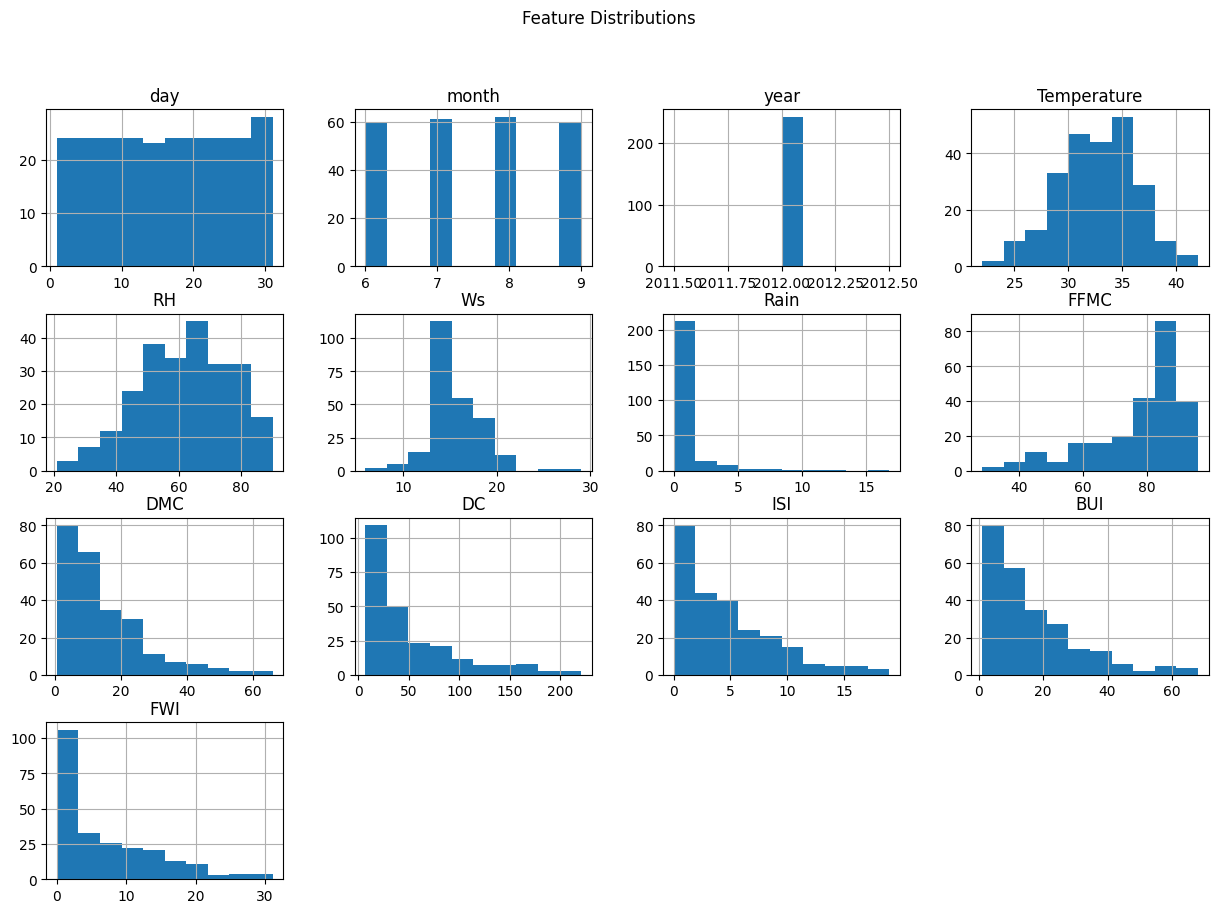

In [13]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Remove extra spaces from string values
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# Display data types
print(df.dtypes)

# Convert columns to numeric where possible
for col in df.columns:
    if col != 'Classes':
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Check again
print(df.dtypes)

# Remove null values created during conversion
df = df.dropna()

# Select numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns

print("Numeric Columns:")
print(numeric_cols)

# Histogram plots
df[numeric_cols].hist(figsize=(15,10))

plt.suptitle("Feature Distributions")

plt.show()

# Boxplot

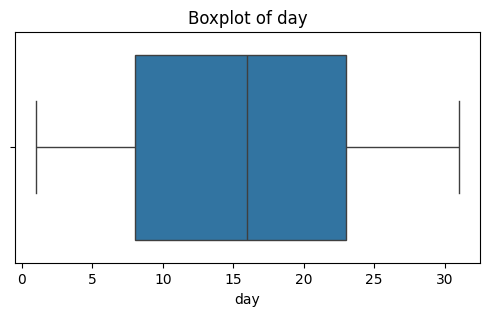

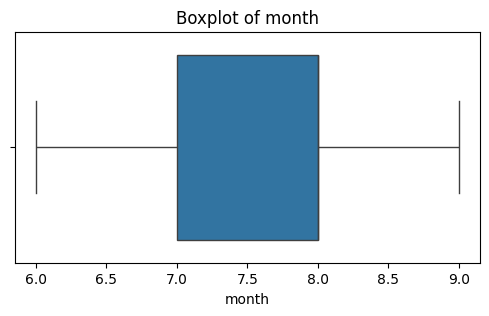

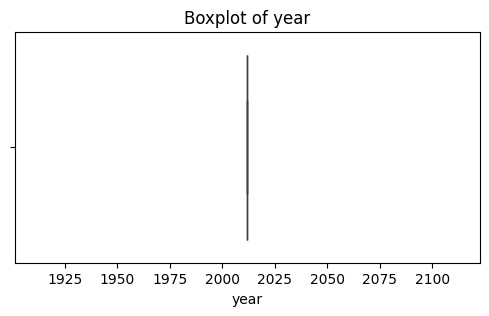

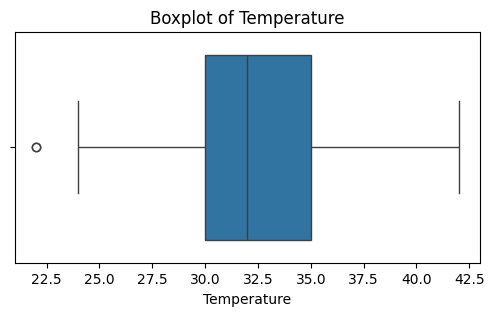

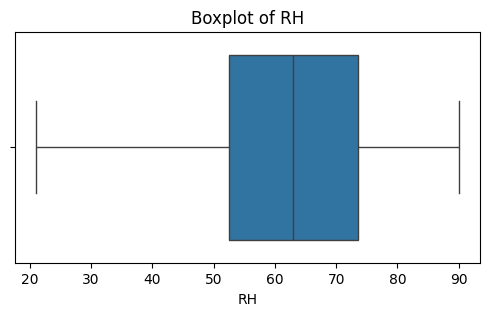

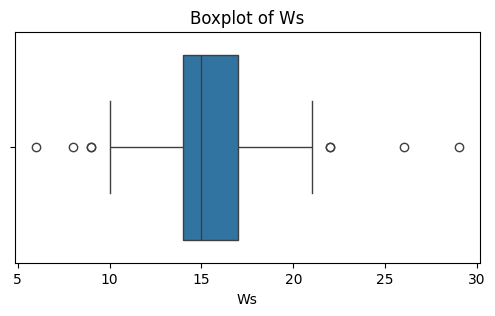

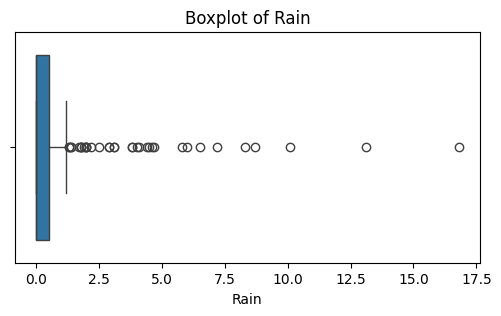

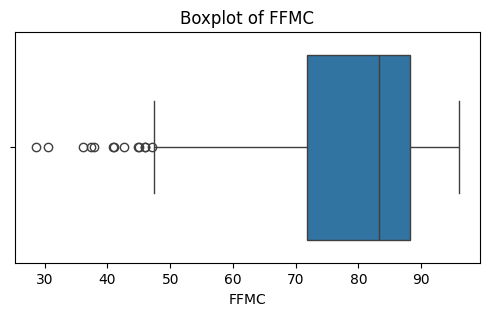

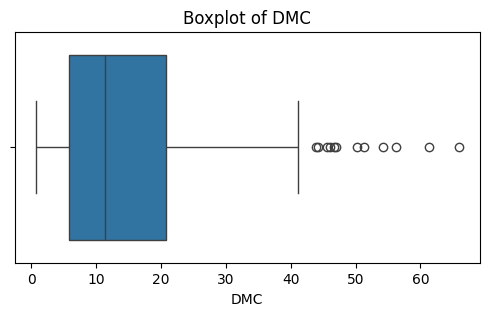

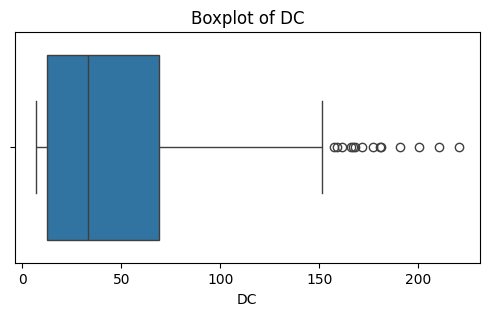

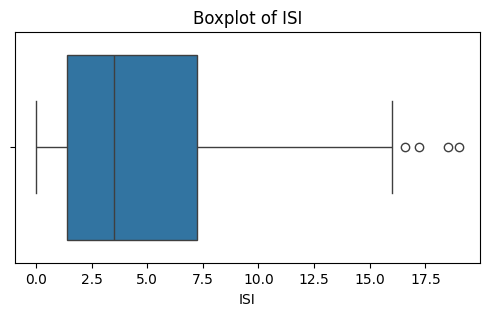

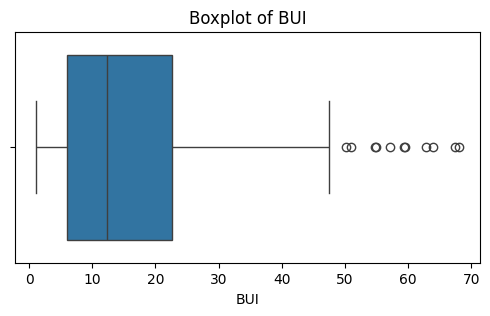

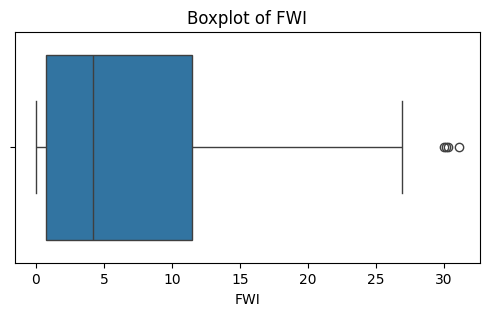

In [14]:
for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


# Count Plot for Wildfire Classes

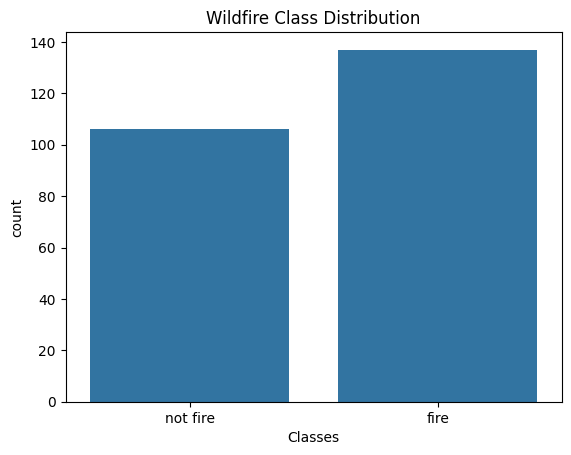

In [15]:
# 8. Count Plot for Wildfire Classes
# -------------------------------

sns.countplot(x='Classes', data=df)
plt.title("Wildfire Class Distribution")
plt.show()


# Correlation Heatmap

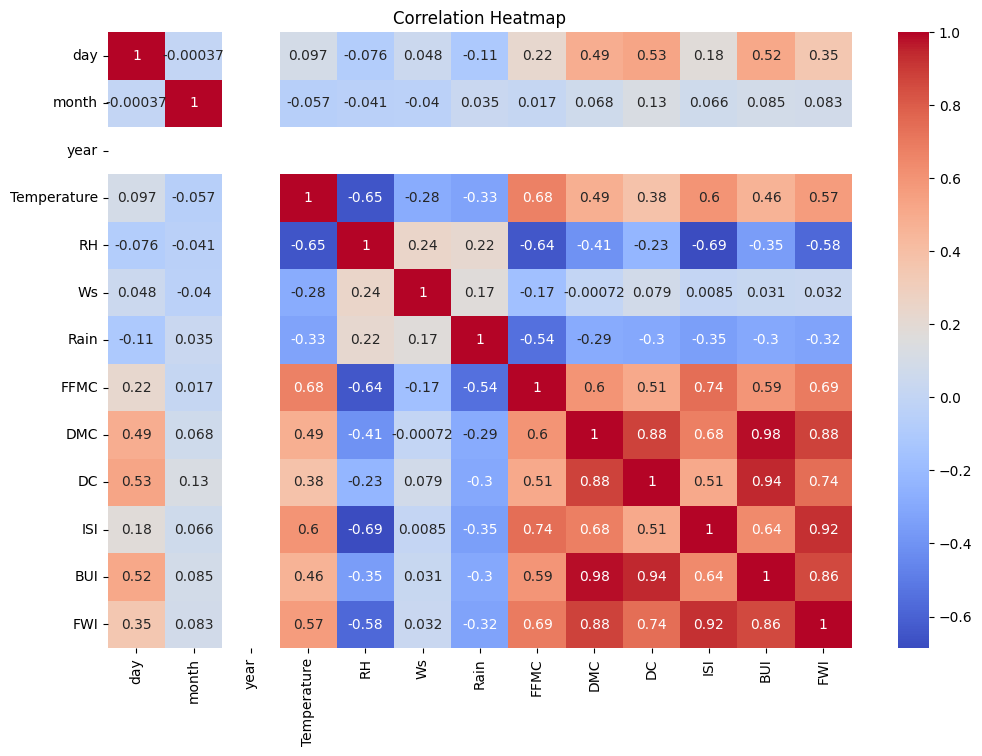

In [16]:
# 9. Correlation Heatmap
# -------------------------------

plt.figure(figsize=(12,8))

sns.heatmap(df[numeric_cols].corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()


# Pair Plot

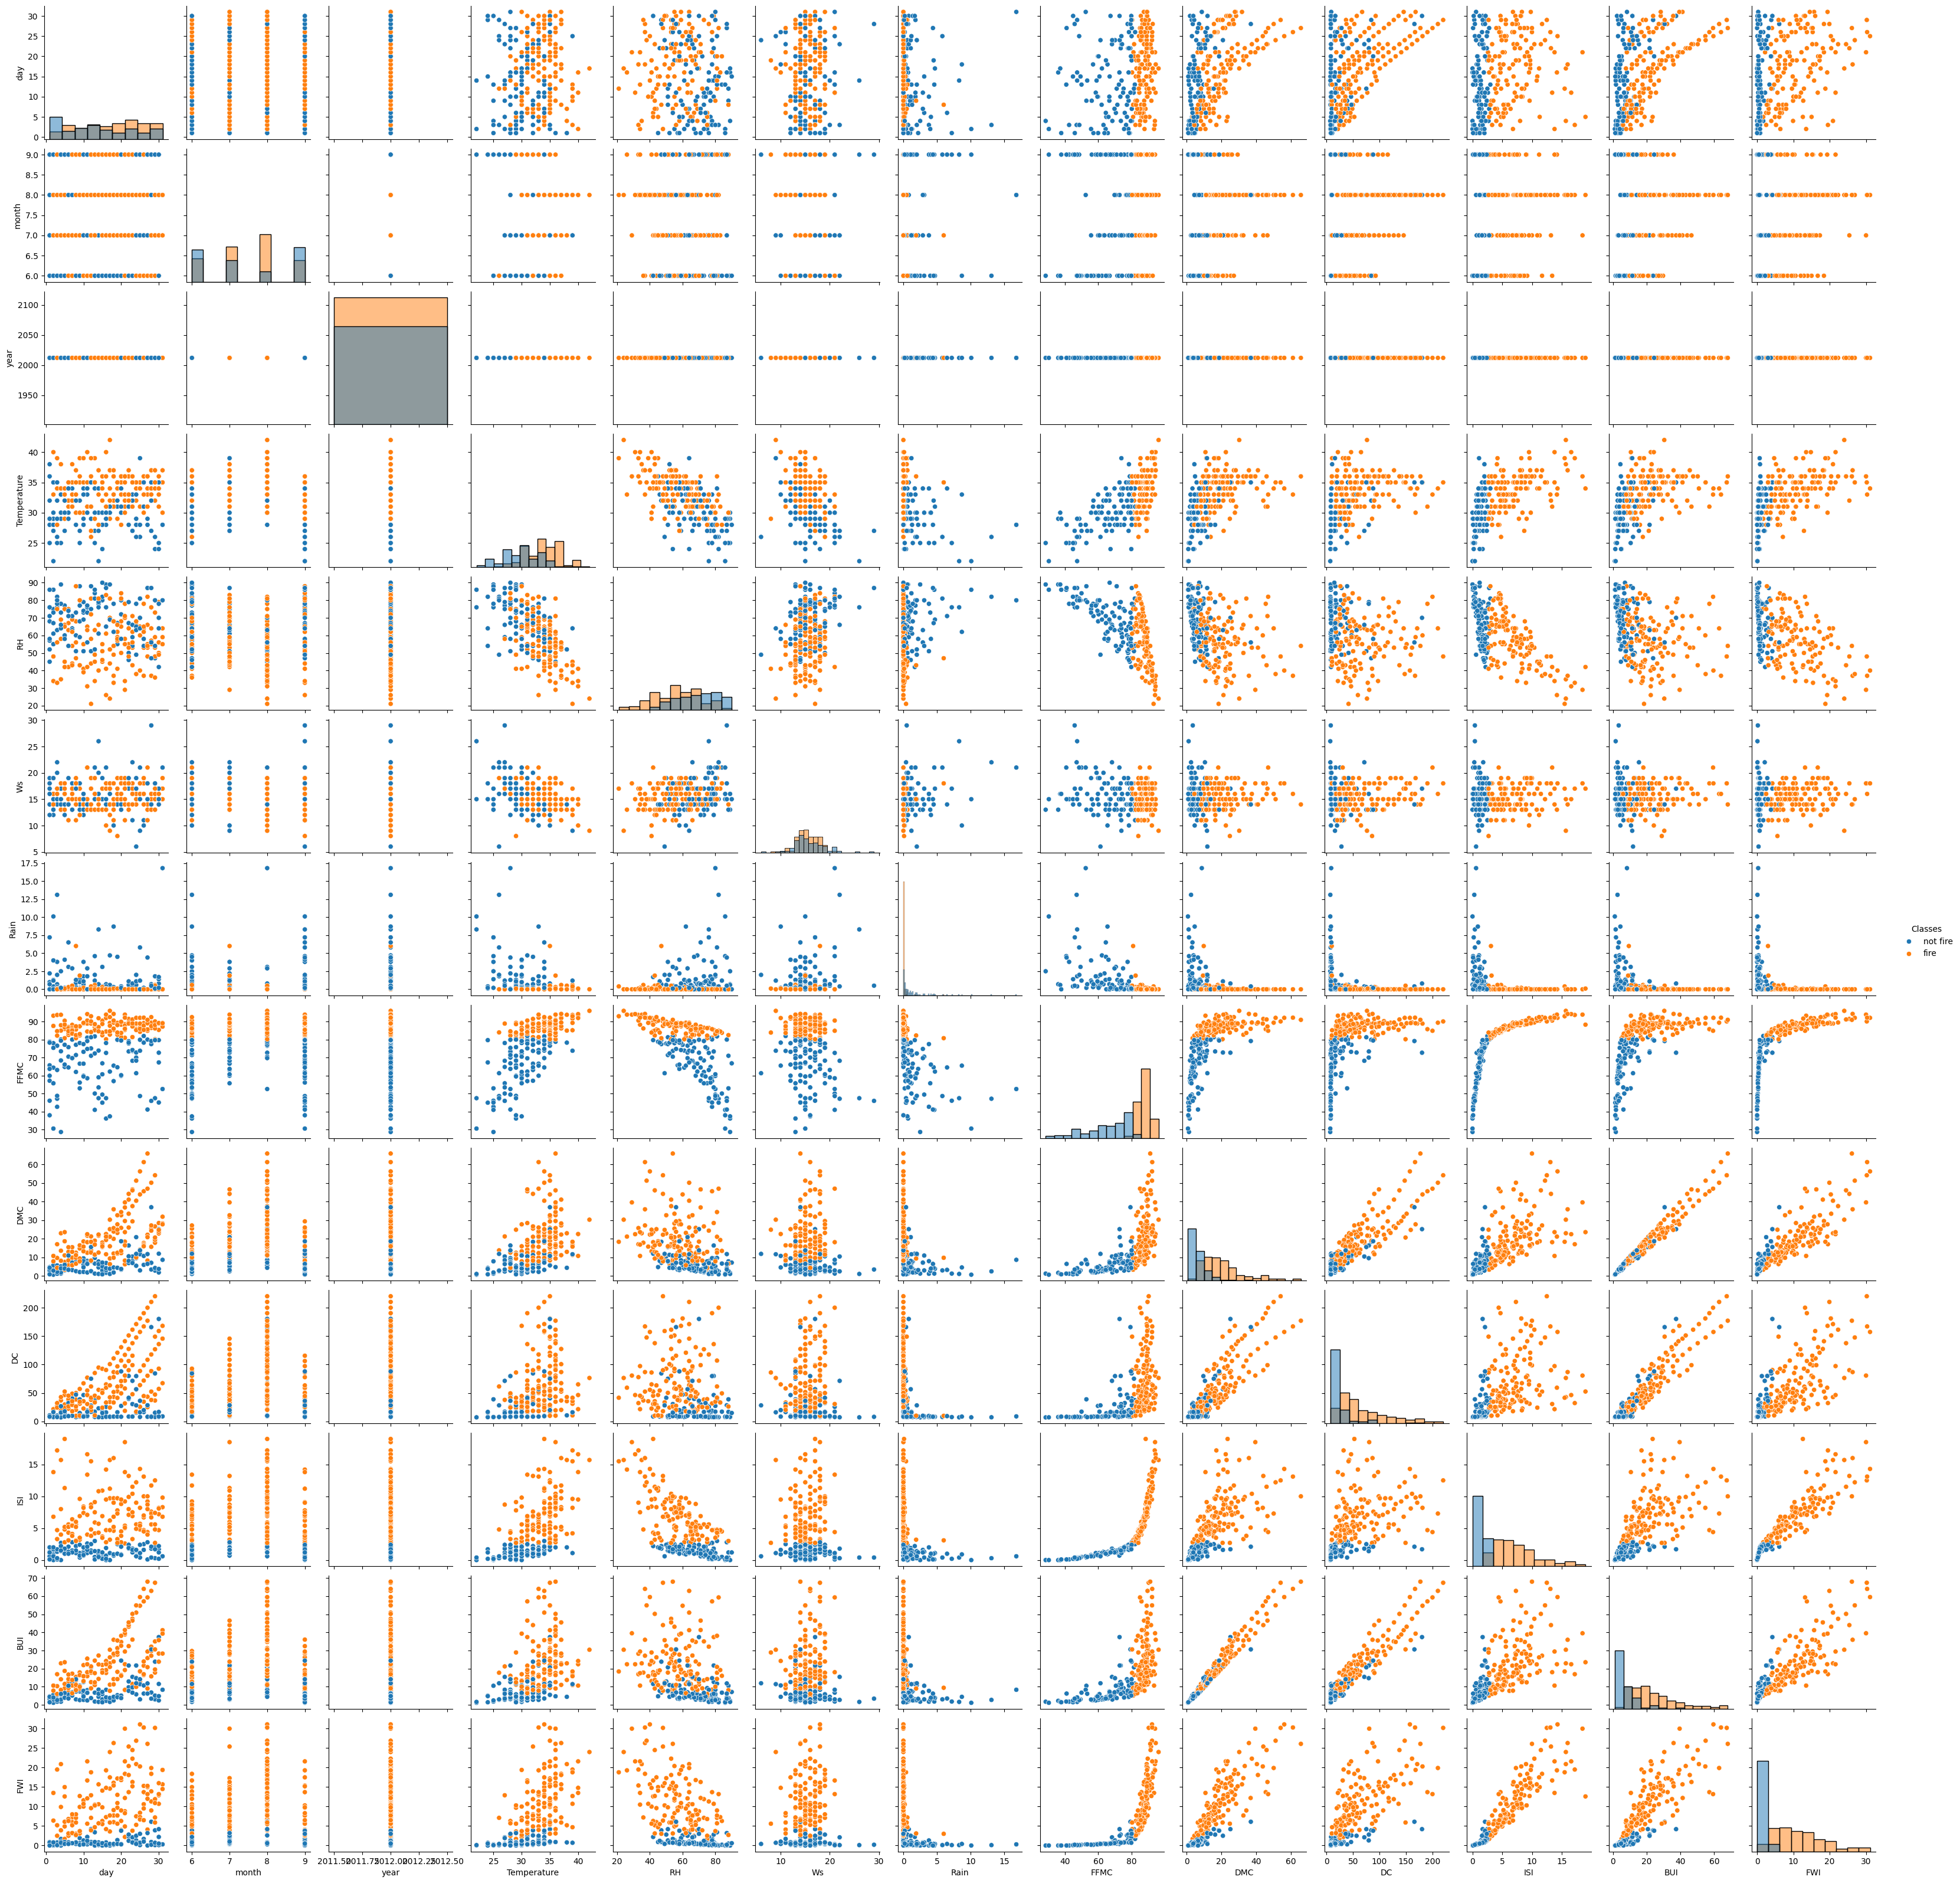

In [17]:
# 10. Pairplot
# -------------------------------

sns.pairplot(df,
             hue='Classes',
             diag_kind='hist')

plt.show()

# Encode Labels

In [18]:
# 11. Encode Labels
# -------------------------------

label_encoder = LabelEncoder()

df['Classes'] = label_encoder.fit_transform(df['Classes'])

print("\nEncoded Classes:")
print(df['Classes'].value_counts())


Encoded Classes:
Classes
0    137
1    106
Name: count, dtype: int64


# Feature Scaling

In [19]:
# 12. Feature Scaling
# -------------------------------

X = df.drop('Classes', axis=1)
y = df['Classes']

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Train Test Split

In [20]:
# 13. Train-Test Split
# -------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Training Shape: (194, 13)
Testing Shape: (49, 13)


In [21]:
# 14. Save Cleaned Dataset
# -------------------------------

cleaned_df = pd.DataFrame(X_scaled, columns=X.columns)
cleaned_df['Classes'] = y.values

cleaned_df.to_csv("cleaned_wildfire_dataset.csv",
                  index=False)

print("\nCleaned dataset saved successfully!")


Cleaned dataset saved successfully!


In [22]:
df = pd.read_csv("cleaned_wildfire_dataset.csv")

**Import Libraries**

In [23]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully")

Libraries imported successfully


**Add cleaned dataset file**

In [ ]:
df = pd.read_csv("cleaned_wildfire_dataset.csv")

print(df.head())

print("\nDataset Shape:")
print(df.shape)

**Features Selection**

In [ ]:
FEATURE_COLS = [
    "Temperature",
    "RH",
    "Ws",
    "Rain",
    "FFMC",
    "DMC",
    "DC",
    "ISI",
    "BUI",
    "FWI"
]

X = df[FEATURE_COLS]

y = df["Classes"]

print("Features Selected Successfully")

Label Encoding

In [24]:
le = LabelEncoder()

y_encoded = le.fit_transform(y)

print("Encoded Classes:")
print(le.classes_)

Encoded Classes:
[0 1]


Feature Scaling

In [25]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature Scaling Completed")

Feature Scaling Completed


Train Test Split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training Size:", len(X_train))
print("Testing Size :", len(X_test))

Training Size: 194
Testing Size : 49


Train SVM Model

In [27]:
svm_model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    random_state=42
)

svm_model.fit(X_train, y_train)

print("SVM Model Trained Successfully")

SVM Model Trained Successfully


SVM Prediction

In [28]:
svm_pred = svm_model.predict(X_test)

print("SVM Prediction Completed")

SVM Prediction Completed


SVM Evaluation

In [29]:
svm_accuracy = accuracy_score(y_test, svm_pred)

svm_precision = precision_score(
    y_test,
    svm_pred,
    average="weighted"
)

svm_recall = recall_score(
    y_test,
    svm_pred,
    average="weighted"
)

svm_f1 = f1_score(
    y_test,
    svm_pred,
    average="weighted"
)

print("SVM Accuracy :", round(svm_accuracy * 100, 2), "%")
print("SVM Precision:", round(svm_precision * 100, 2), "%")
print("SVM Recall   :", round(svm_recall * 100, 2), "%")
print("SVM F1-Score :", round(svm_f1 * 100, 2), "%")

SVM Accuracy : 95.92 %
SVM Precision: 95.92 %
SVM Recall   : 95.92 %
SVM F1-Score : 95.92 %


SVM Confusion Matrix

In [30]:
svm_cm = confusion_matrix(y_test, svm_pred)

print("SVM Confusion Matrix")

print(svm_cm)

SVM Confusion Matrix
[[27  1]
 [ 1 20]]


Train Random Forest

In [31]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained")

Random Forest Model Trained


In [32]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained")

Random Forest Model Trained


Random Forest Evaluation

In [35]:
rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

rf_precision = precision_score(
    y_test,
    rf_pred,
    average="weighted"
)

rf_recall = recall_score(
    y_test,
    rf_pred,
    average="weighted"
)

rf_f1 = f1_score(
    y_test,
    rf_pred,
    average="weighted"
)

print("RF Accuracy :", round(rf_accuracy * 100, 2), "%")
print("RF Precision:", round(rf_precision * 100, 2), "%")
print("RF Recall   :", round(rf_recall * 100, 2), "%")
print("RF F1-Score :", round(rf_f1 * 100, 2), "%")

RF Accuracy : 95.92 %
RF Precision: 95.92 %
RF Recall   : 95.92 %
RF F1-Score : 95.92 %


In [36]:
rf_cm = confusion_matrix(y_test, rf_pred)

print("Random Forest Confusion Matrix")

print(rf_cm)

Random Forest Confusion Matrix
[[27  1]
 [ 1 20]]


Train Gradient Boosting Model

In [38]:
xgb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(X_train, y_train)

print("Gradient Boosting Model Trained")

Gradient Boosting Model Trained


Gradient Boosting Prediction

In [39]:
xgb_pred = xgb_model.predict(X_test)

print("Gradient Boosting Prediction Completed")

Gradient Boosting Prediction Completed


Gradient Boosting Evaluation

In [40]:
xgb_accuracy = accuracy_score(y_test, xgb_pred)

xgb_precision = precision_score(
    y_test,
    xgb_pred,
    average="weighted"
)

xgb_recall = recall_score(
    y_test,
    xgb_pred,
    average="weighted"
)

xgb_f1 = f1_score(
    y_test,
    xgb_pred,
    average="weighted"
)

print("GB Accuracy :", round(xgb_accuracy * 100, 2), "%")
print("GB Precision:", round(xgb_precision * 100, 2), "%")
print("GB Recall   :", round(xgb_recall * 100, 2), "%")
print("GB F1-Score :", round(xgb_f1 * 100, 2), "%")

GB Accuracy : 97.96 %
GB Precision: 98.03 %
GB Recall   : 97.96 %
GB F1-Score : 97.95 %


Gradient Boosting Confusion Matrix

In [41]:
xgb_cm = confusion_matrix(y_test, xgb_pred)

print("Gradient Boosting Confusion Matrix")

print(xgb_cm)

Gradient Boosting Confusion Matrix
[[28  0]
 [ 1 20]]


Classification Reports

In [42]:
print("SVM Classification Report")

print(classification_report(y_test, svm_pred))

SVM Classification Report
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        28
           1       0.95      0.95      0.95        21

    accuracy                           0.96        49
   macro avg       0.96      0.96      0.96        49
weighted avg       0.96      0.96      0.96        49



In [43]:
print("Random Forest Classification Report")

print(classification_report(y_test, rf_pred))

Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        28
           1       0.95      0.95      0.95        21

    accuracy                           0.96        49
   macro avg       0.96      0.96      0.96        49
weighted avg       0.96      0.96      0.96        49



In [44]:
print("Gradient Boosting Classification Report")

print(classification_report(y_test, xgb_pred))

Gradient Boosting Classification Report
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        28
           1       1.00      0.95      0.98        21

    accuracy                           0.98        49
   macro avg       0.98      0.98      0.98        49
weighted avg       0.98      0.98      0.98        49



Model Performance Comparison

In [45]:
comparison_df = pd.DataFrame({

    "Model": [
        "SVM",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Accuracy": [
        svm_accuracy * 100,
        rf_accuracy * 100,
        xgb_accuracy * 100
    ],

    "Precision": [
        svm_precision * 100,
        rf_precision * 100,
        xgb_precision * 100
    ],

    "Recall": [
        svm_recall * 100,
        rf_recall * 100,
        xgb_recall * 100
    ],

    "F1-Score": [
        svm_f1 * 100,
        rf_f1 * 100,
        xgb_f1 * 100
    ]
})

print(comparison_df)

               Model   Accuracy  Precision     Recall   F1-Score
0                SVM  95.918367  95.918367  95.918367  95.918367
1      Random Forest  95.918367  95.918367  95.918367  95.918367
2  Gradient Boosting  97.959184  98.029557  97.959184  97.952198


Best Model

In [46]:
best_model = comparison_df.loc[
    comparison_df["F1-Score"].idxmax()
]

print("Best Model Details")

print(best_model)

Best Model Details
Model        Gradient Boosting
Accuracy             97.959184
Precision            98.029557
Recall               97.959184
F1-Score             97.952198
Name: 2, dtype: object


Prediction Results

In [47]:
results_df = pd.DataFrame({

    "Actual": le.inverse_transform(y_test),

    "SVM_Prediction":
        le.inverse_transform(svm_pred),

    "RF_Prediction":
        le.inverse_transform(rf_pred),

    "GB_Prediction":
        le.inverse_transform(xgb_pred)

})

results_df.to_csv(
    "prediction_results.csv",
    index=False
)

print("Prediction Results Saved")

Prediction Results Saved
